# 02 — Part 1: Baseline Image Captioning — CLEAN V2
## Frozen ResNet50 + LSTM Decoder

This notebook is the **new clean Part-1 run** and is compatible only with the
new Flickr8k preprocessing pipeline.

### Safety guarantees in this V2 notebook
- Requires `preprocessing_audit.json` from the new Notebook 01.
- Computes a preprocessing SHA-256 fingerprint.
- Refuses incompatible preprocessing artifacts.
- Uses a new output folder: `/kaggle/working/part1_baseline_v2`.
- Does **not** resume old checkpoints unless explicitly enabled.
- Stores the preprocessing fingerprint in checkpoints, metrics, model bundles,
  and `part1_manifest.json`.
- Uses raw Flickr8k images for qualitative test examples when the dataset is attached.

The model architecture remains the controlled baseline required by the project:
**same frozen ResNet50 encoder + LSTM caption decoder**.


## 1. Imports and Reproducibility

In [1]:
import os
import gc
import json
import hashlib
import time
import math
import random
import shutil
import textwrap
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import h5py
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
import torchvision.transforms as T

from tqdm.auto import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
class CFG:
    SEED = 42

    # If None, the notebook searches /kaggle/working and /kaggle/input.
    PREP_DIR = None
    RAW_IMAGES_DIR = None

    # New clean run: old checkpoints are ignored by default.
    RESUME_FROM_CHECKPOINT = False

    # Model
    ENCODER_NAME = "ResNet50 ImageNet-V2 (frozen; precomputed spatial features)"
    DECODER_NAME = "Single-layer LSTM merge decoder"
    EMBED_DIM = 256
    HIDDEN_DIM = 512
    NUM_LAYERS = 1
    DROPOUT = 0.5

    # Optimization
    BATCH_SIZE = 128
    LR = 3e-4
    WEIGHT_DECAY = 1e-5
    OPTIMIZER_NAME = "Adam"
    GRAD_CLIP = 5.0
    MAX_EPOCHS = 30

    # Early stopping is based on full validation BLEU-4.
    PATIENCE = 6
    MIN_DELTA = 1e-5

    NUM_WORKERS = 2

    # Optional Kaggle safety budget.
    # Set to None to disable the time-budget check.
    TIME_BUDGET_HOURS = 8.0
    TIME_SAFETY_MARGIN_MIN = 15

    # Output
    OUTPUT_DIR = "/kaggle/working/part1_baseline_v2"

    LAST_CKPT = "last_checkpoint.pt"
    BEST_CKPT = "best_checkpoint.pt"
    FINAL_MODEL = "baseline_lstm_final_model.pt"
    FULL_PRESENTATION_MODEL = "baseline_lstm_full_presentation_bundle.pt"
    PRESENTATION_SCRIPT = "presentation_inference.py"
    PRESENTATION_ZIP = "part1_presentation_package.zip"


set_seed(CFG.SEED)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

print("Output directory:", CFG.OUTPUT_DIR)

Output directory: /kaggle/working/part1_baseline_v2


## 3. Locate Preprocessed Artifacts

The required preprocessing directory must contain:

- `manifest.json`
- `vocab.json`
- `captions.csv`
- `token_ids.npy`
- `features.h5`
- `feature_index.json`

In [3]:

REQUIRED_PREP_FILES = {
    "manifest.json",
    "preprocessing_audit.json",
    "vocab.json",
    "captions.csv",
    "token_ids.npy",
    "splits.json",
    "transform_config.json",
    "features.h5",
    "feature_index.json",
}


def is_new_preprocessed_dir(path):
    path = Path(path)

    if not path.is_dir():
        return False

    present = {
        p.name
        for p in path.iterdir()
        if p.is_file()
    }

    if not REQUIRED_PREP_FILES.issubset(present):
        return False

    try:
        with open(
            path / "manifest.json",
            "r",
            encoding="utf-8",
        ) as f:
            candidate_manifest = json.load(f)

        with open(
            path / "preprocessing_audit.json",
            "r",
            encoding="utf-8",
        ) as f:
            candidate_audit = json.load(f)

        return (
            candidate_manifest.get("artifact_version") == 1
            and candidate_manifest.get("dataset") == "Flickr8k"
            and int(candidate_audit.get("final_unique_images", 0)) > 7000
            and int(candidate_audit.get("final_caption_rows", 0)) > 30000
        )

    except Exception:
        return False


def find_preprocessed_dir():
    if CFG.PREP_DIR is not None:
        assert is_new_preprocessed_dir(CFG.PREP_DIR), (
            "CFG.PREP_DIR is not the NEW preprocessing output. "
            "It must contain preprocessing_audit.json and artifact_version=1."
        )
        return str(CFG.PREP_DIR)

    candidates = []

    # Search working first (same Kaggle session), then attached datasets.
    for root in ["/kaggle/working", "/kaggle/input"]:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            if not REQUIRED_PREP_FILES.issubset(set(filenames)):
                continue

            if not is_new_preprocessed_dir(dirpath):
                continue

            with open(
                os.path.join(dirpath, "preprocessing_audit.json"),
                "r",
                encoding="utf-8",
            ) as f:
                audit = json.load(f)

            candidates.append(
                (
                    int(audit["final_unique_images"]),
                    int(audit["final_caption_rows"]),
                    dirpath,
                )
            )

    if not candidates:
        return None

    # Prefer the complete Flickr8k artifact set.
    candidates.sort(reverse=True)
    return candidates[0][2]


PREP_DIR = find_preprocessed_dir()

assert PREP_DIR is not None, (
    "Could not find the NEW preprocessing artifacts. "
    "Run Notebook 01 CLEAN preprocessing first or attach its output as a Kaggle input."
)

print("NEW preprocessing directory:", PREP_DIR)


NEW preprocessing directory: /kaggle/input/datasets/amirmrt04/dl-dataset/preprocessed


## 4. Load Manifest, Vocabulary, Captions, Tokens, and Feature Metadata

In [4]:

with open(
    os.path.join(PREP_DIR, "manifest.json"),
    "r",
    encoding="utf-8",
) as f:
    manifest = json.load(f)

with open(
    os.path.join(PREP_DIR, "preprocessing_audit.json"),
    "r",
    encoding="utf-8",
) as f:
    preprocessing_audit = json.load(f)

with open(
    os.path.join(PREP_DIR, "vocab.json"),
    "r",
    encoding="utf-8",
) as f:
    vocab = json.load(f)

with open(
    os.path.join(PREP_DIR, "feature_index.json"),
    "r",
    encoding="utf-8",
) as f:
    feature_index = json.load(f)

captions_df = pd.read_csv(
    os.path.join(PREP_DIR, "captions.csv")
)

TOKEN_IDS_PATH = os.path.join(
    PREP_DIR,
    "token_ids.npy",
)

FEATURES_H5_PATH = os.path.join(
    PREP_DIR,
    "features.h5",
)

token_ids = np.load(
    TOKEN_IDS_PATH,
    mmap_mode="r",
)

word2idx = vocab["word2idx"]
idx2word = vocab["idx2word"]

PAD_ID = int(vocab["special_tokens"]["pad_id"])
START_ID = int(vocab["special_tokens"]["start_id"])
END_ID = int(vocab["special_tokens"]["end_id"])
UNK_ID = int(vocab["special_tokens"]["unk_id"])

VOCAB_SIZE = len(idx2word)
MAX_LEN = int(manifest["text"]["max_len"])
FEAT_DIM = int(feature_index["feature_dim"])
NUM_TOKENS = int(feature_index["num_tokens"])

GEN_MAX_NEW_TOKENS = MAX_LEN - 1


def preprocessing_fingerprint(prep_dir):
    """
    Fingerprint the preprocessing choices that must be identical
    between Part 1 and Part 2.
    """
    sha = hashlib.sha256()

    for filename in [
        "manifest.json",
        "vocab.json",
        "splits.json",
        "feature_index.json",
    ]:
        path = os.path.join(prep_dir, filename)

        with open(path, "rb") as f:
            sha.update(filename.encode("utf-8"))
            sha.update(f.read())

    return sha.hexdigest()


PREPROCESSING_FINGERPRINT = preprocessing_fingerprint(
    PREP_DIR
)

# ------------------------------------------------------------
# Strong compatibility / leakage / schema checks
# ------------------------------------------------------------
assert manifest["artifact_version"] == 1
assert manifest["dataset"] == "Flickr8k"
assert manifest["text"]["vocabulary_built_from"] == "train"
assert manifest["text"]["max_len_built_from"] == "train"

assert len(captions_df) == token_ids.shape[0]
assert token_ids.shape[1] == MAX_LEN

assert int(manifest["counts"]["captions"]) == len(captions_df)
assert int(manifest["counts"]["unique_images"]) == captions_df["image"].nunique()

assert int(preprocessing_audit["final_caption_rows"]) == len(captions_df)
assert int(preprocessing_audit["final_unique_images"]) == captions_df["image"].nunique()

assert VOCAB_SIZE == len(word2idx)
assert int(manifest["text"]["vocab_size"]) == VOCAB_SIZE

assert PAD_ID == int(manifest["text"]["pad_id"])
assert START_ID == int(manifest["text"]["start_id"])
assert END_ID == int(manifest["text"]["end_id"])
assert UNK_ID == int(manifest["text"]["unk_id"])

assert captions_df["feature_idx"].notna().all()
assert NUM_TOKENS == 49
assert FEAT_DIM == 2048

expected_split_images = manifest["split"]["images"]
actual_split_images = (
    captions_df.groupby("split")["image"]
    .nunique()
    .to_dict()
)

for split in ["train", "val", "test"]:
    assert int(expected_split_images[split]) == int(actual_split_images[split])

print("Dataset:", manifest["dataset"])
print("Captions:", len(captions_df))
print("Unique images:", captions_df["image"].nunique())
print("Vocabulary size:", VOCAB_SIZE)
print("MAX_LEN:", MAX_LEN)
print("Feature shape per image:", (NUM_TOKENS, FEAT_DIM))
print("Preprocessing fingerprint:", PREPROCESSING_FINGERPRINT)
print("Split summary:")

display(
    captions_df.groupby("split").agg(
        captions=("image", "size"),
        images=("image", "nunique"),
    )
)

print("\nNEW PREPROCESSING COMPATIBILITY CHECKS PASSED.")


Dataset: Flickr8k
Captions: 40455
Unique images: 8091
Vocabulary size: 2659
MAX_LEN: 20
Feature shape per image: (49, 2048)
Preprocessing fingerprint: 9076e5061367af04b11a8549a08d3a5ea65b5c89c0b41cf8c4838ecf4f409df7
Split summary:


,captions,images
split,,
test,4050,810
train,32360,6472
val,4045,809



NEW PREPROCESSING COMPATIBILITY CHECKS PASSED.


## 5. Dataset and DataLoader

The HDF5 handle is opened lazily **inside each worker process**, avoiding the unsafe pattern of sharing an HDF5 file handle across multiprocessing workers.

In [5]:
class CaptionFeatureDataset(Dataset):
    def __init__(self, captions_df, token_ids_path, h5_path, split):
        self.df = captions_df[captions_df["split"] == split].reset_index()
        self.original_indices = self.df["index"].to_numpy(dtype=np.int64)

        # Memory-mapped token matrix; safe and compact.
        self.token_ids_path = token_ids_path
        self._token_ids = None

        self.h5_path = h5_path
        self._h5 = None

        self.images = self.df["image"].astype(str).to_numpy()
        self.clean_captions = self.df["clean_caption"].astype(str).to_numpy()
        self.raw_captions = self.df["caption"].astype(str).to_numpy()
        self.feature_indices = self.df["feature_idx"].to_numpy(dtype=np.int64)

    def _get_tokens(self):
        if self._token_ids is None:
            self._token_ids = np.load(self.token_ids_path, mmap_mode="r")
        return self._token_ids

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
        return self._h5

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        h5 = self._get_h5()
        all_tokens = self._get_tokens()

        feat_idx = int(self.feature_indices[idx])

        # Spatial ResNet50 features: (49, 2048)
        spatial_feat = h5["features"][feat_idx]

        # Baseline LSTM uses a global image vector.
        global_feat = spatial_feat.astype(np.float32).mean(axis=0)

        tokens = np.asarray(
            all_tokens[self.original_indices[idx]],
            dtype=np.int64,
        )

        return (
            torch.from_numpy(global_feat),
            torch.from_numpy(tokens),
        )

    def __getstate__(self):
        # Do not serialize active HDF5/memmap handles into worker processes.
        state = self.__dict__.copy()
        state["_h5"] = None
        state["_token_ids"] = None
        return state

    def close(self):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None


def make_loader(split, shuffle):
    ds = CaptionFeatureDataset(
        captions_df=captions_df,
        token_ids_path=os.path.join(PREP_DIR, "token_ids.npy"),
        h5_path=FEATURES_H5_PATH,
        split=split,
    )

    generator = torch.Generator()
    generator.manual_seed(CFG.SEED)

    loader = DataLoader(
        ds,
        batch_size=CFG.BATCH_SIZE,
        shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
        # Non-persistent workers avoid stale HDF5 handles across stages.
        persistent_workers=False,
        generator=generator if shuffle else None,
    )

    return ds, loader


train_ds, train_loader = make_loader("train", shuffle=True)
val_ds, val_loader = make_loader("val", shuffle=False)
test_ds, test_loader = make_loader("test", shuffle=False)

print("Train captions:", len(train_ds))
print("Validation captions:", len(val_ds))
print("Test captions:", len(test_ds))

# Shape sanity check without opening HDF5 through Dataset before workers start.
with h5py.File(FEATURES_H5_PATH, "r") as h5:
    first_feature_shape = h5["features"][0].shape

print("Cached spatial feature shape:", first_feature_shape)
print("Token matrix shape:", token_ids.shape)
assert tuple(first_feature_shape) == (NUM_TOKENS, FEAT_DIM)

Train captions: 32360
Validation captions: 4045
Test captions: 4050
Cached spatial feature shape: (49, 2048)
Token matrix shape: (40455, 20)


## 6. Baseline LSTM Decoder Architecture

For each decoding step:

- word embedding: `256`
- projected image embedding: `256`
- concatenated LSTM input: `512`
- LSTM hidden dimension: `512`
- output: vocabulary logits

The image feature is provided at every time step (merge architecture).

In [6]:
class CaptionLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        feat_dim,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_id,
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.feat_dim = feat_dim
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pad_id = pad_id

        self.image_proj = nn.Linear(feat_dim, embed_dim)

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_id,
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_feat, input_tokens):
        # img_feat:     (B, feat_dim)
        # input_tokens: (B, T)

        img_embed = torch.tanh(self.image_proj(img_feat))      # (B, E)
        word_embed = self.embedding(input_tokens)              # (B, T, E)

        img_embed_rep = img_embed.unsqueeze(1).expand(
            -1, word_embed.size(1), -1
        )

        lstm_input = torch.cat(
            [word_embed, img_embed_rep],
            dim=-1,
        )                                                       # (B, T, 2E)

        lstm_output, _ = self.lstm(lstm_input)
        lstm_output = self.dropout(lstm_output)

        logits = self.fc(lstm_output)                           # (B, T, V)
        return logits

    @torch.no_grad()
    def generate(
        self,
        img_feat,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
    ):
        """
        Greedy autoregressive decoding.

        Returns
        -------
        generated_ids : LongTensor, shape (B, max_new_tokens)
        finished       : BoolTensor, shape (B,)
                         True iff <end> was generated.
        """
        self.eval()

        batch_size = img_feat.size(0)

        img_embed = torch.tanh(
            self.image_proj(img_feat)
        ).unsqueeze(1)                                         # (B, 1, E)

        input_token = torch.full(
            (batch_size, 1),
            start_id,
            dtype=torch.long,
            device=img_feat.device,
        )

        hidden = None

        generated = torch.full(
            (batch_size, max_new_tokens),
            pad_id,
            dtype=torch.long,
            device=img_feat.device,
        )

        finished = torch.zeros(
            batch_size,
            dtype=torch.bool,
            device=img_feat.device,
        )

        for t in range(max_new_tokens):
            word_embed = self.embedding(input_token)
            lstm_input = torch.cat([word_embed, img_embed], dim=-1)

            out, hidden = self.lstm(lstm_input, hidden)
            logits = self.fc(out.squeeze(1))

            # These tokens should never be emitted as ordinary generated words.
            logits[:, pad_id] = -torch.inf
            logits[:, start_id] = -torch.inf

            next_token = logits.argmax(dim=-1)

            # Already-finished sequences stay padded.
            next_token = torch.where(
                finished,
                torch.full_like(next_token, pad_id),
                next_token,
            )

            generated[:, t] = next_token

            just_finished = (~finished) & (next_token == end_id)
            finished = finished | just_finished

            # For finished sequences, feeding <end> is harmless.
            next_input = torch.where(
                finished,
                torch.full_like(next_token, end_id),
                next_token,
            )
            input_token = next_input.unsqueeze(1)

            if finished.all():
                break

        return generated, finished


model = CaptionLSTM(
    vocab_size=VOCAB_SIZE,
    feat_dim=FEAT_DIM,
    embed_dim=CFG.EMBED_DIM,
    hidden_dim=CFG.HIDDEN_DIM,
    num_layers=CFG.NUM_LAYERS,
    dropout=CFG.DROPOUT,
    pad_id=PAD_ID,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Approx. decoder size (fp32): {total_params * 4 / 1e6:.1f} MB")

CaptionLSTM(
  (image_proj): Linear(in_features=2048, out_features=256, bias=True)
  (embedding): Embedding(2659, 256, padding_idx=0)
  (lstm): LSTM(512, 512, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2659, bias=True)
)

Total parameters: 4,670,563
Trainable parameters: 4,670,563
Approx. decoder size (fp32): 18.7 MB


## 7. Loss, Optimizer, and Checkpoint Utilities

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY,
)

AMP_ENABLED = DEVICE.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

last_ckpt_path = os.path.join(CFG.OUTPUT_DIR, CFG.LAST_CKPT)
best_ckpt_path = os.path.join(CFG.OUTPUT_DIR, CFG.BEST_CKPT)


def cfg_to_dict():
    return {
        key: value
        for key, value in vars(CFG).items()
        if not key.startswith("_")
    }


def save_checkpoint(
    path,
    epoch,
    best_val_bleu4,
    epochs_without_improvement,
    history,
):
    torch.save(
        {
            "format_version": 3,
            "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_bleu4": float(best_val_bleu4),
            "epochs_without_improvement": int(epochs_without_improvement),
            "history": history,
            "cfg": cfg_to_dict(),
            "model_config": {
                "vocab_size": VOCAB_SIZE,
                "feat_dim": FEAT_DIM,
                "embed_dim": CFG.EMBED_DIM,
                "hidden_dim": CFG.HIDDEN_DIM,
                "num_layers": CFG.NUM_LAYERS,
                "dropout": CFG.DROPOUT,
                "pad_id": PAD_ID,
            },
        },
        path,
    )


def load_training_checkpoint(path):
    checkpoint = torch.load(path, map_location=DEVICE)

    assert checkpoint.get("preprocessing_fingerprint") == PREPROCESSING_FINGERPRINT, (
        "Checkpoint was created from different preprocessing artifacts."
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint


def load_best_model(path):
    checkpoint = torch.load(path, map_location=DEVICE)
    assert checkpoint.get("preprocessing_fingerprint") == PREPROCESSING_FINGERPRINT, (
        "Best checkpoint was created from different preprocessing artifacts."
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return checkpoint


def ids_to_words(ids):
    words = []

    for token_id in ids:
        token_id = int(token_id)

        if token_id == END_ID:
            break

        if token_id in (PAD_ID, START_ID):
            continue

        if 0 <= token_id < len(idx2word):
            words.append(idx2word[token_id])

    return words

/tmp/ipykernel_23/1249709885.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


## 8. Training and Validation Utilities

In [8]:
def train_one_epoch(loader):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    for features, tokens in tqdm(loader, desc="Training", leave=False):
        features = features.to(DEVICE, non_blocking=True)
        tokens = tokens.to(DEVICE, non_blocking=True)

        # Teacher forcing:
        # input : <start> w1 w2 ...
        # target: w1      w2 ... <end>
        input_tokens = tokens[:, :-1]
        target_tokens = tokens[:, 1:]

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(features, input_tokens)

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                target_tokens.reshape(-1),
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CFG.GRAD_CLIP,
        )

        scaler.step(optimizer)
        scaler.update()

        n_valid_tokens = (target_tokens != PAD_ID).sum().item()

        total_loss += loss.item() * n_valid_tokens
        total_tokens += n_valid_tokens

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def evaluate_loss(loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    for features, tokens in tqdm(loader, desc="Validation loss", leave=False):
        features = features.to(DEVICE, non_blocking=True)
        tokens = tokens.to(DEVICE, non_blocking=True)

        input_tokens = tokens[:, :-1]
        target_tokens = tokens[:, 1:]

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(features, input_tokens)

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                target_tokens.reshape(-1),
            )

        n_valid_tokens = (target_tokens != PAD_ID).sum().item()

        total_loss += loss.item() * n_valid_tokens
        total_tokens += n_valid_tokens

    return total_loss / max(total_tokens, 1)

## 9. BLEU Evaluation Utilities

BLEU is computed at the **image level** using **all human reference captions** for each image.

Validation BLEU is calculated on the **entire validation set every epoch**, and the best checkpoint is selected using **BLEU-4**.

In [9]:
def build_reference_dict(split_df):
    references = defaultdict(list)

    for row in split_df.itertuples(index=False):
        references[str(row.image)].append(
            str(row.clean_caption).split()
        )

    return references


image_to_feature_idx = (
    captions_df[["image", "feature_idx"]]
    .drop_duplicates("image")
    .set_index("image")["feature_idx"]
    .astype(int)
    .to_dict()
)


@torch.no_grad()
def evaluate_bleu(
    references,
    batch_size=None,
):
    model.eval()

    if batch_size is None:
        batch_size = CFG.BATCH_SIZE

    image_names = sorted(references.keys())

    hypotheses = []
    reference_list = []
    finished_flags = []

    with h5py.File(FEATURES_H5_PATH, "r") as h5:
        for start in tqdm(
            range(0, len(image_names), batch_size),
            desc="BLEU decoding",
            leave=False,
        ):
            batch_names = image_names[start:start + batch_size]

            features = []

            for image_name in batch_names:
                feature_idx = image_to_feature_idx[image_name]

                spatial = h5["features"][feature_idx].astype(np.float32)
                global_feature = spatial.mean(axis=0)

                features.append(global_feature)

            features = torch.from_numpy(
                np.stack(features)
            ).to(DEVICE)

            generated_ids, finished = model.generate(
                img_feat=features,
                start_id=START_ID,
                end_id=END_ID,
                pad_id=PAD_ID,
                max_new_tokens=GEN_MAX_NEW_TOKENS,
            )

            generated_ids = generated_ids.cpu().numpy()
            finished = finished.cpu().numpy()

            for row_idx, image_name in enumerate(batch_names):
                hypotheses.append(
                    ids_to_words(generated_ids[row_idx])
                )

                reference_list.append(
                    references[image_name]
                )

                finished_flags.append(
                    bool(finished[row_idx])
                )

    smoothing = SmoothingFunction().method1

    bleu1 = corpus_bleu(
        reference_list,
        hypotheses,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoothing,
    )

    bleu4 = corpus_bleu(
        reference_list,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing,
    )

    return {
        "bleu1": float(bleu1),
        "bleu4": float(bleu4),
        "hypotheses": hypotheses,
        "references": reference_list,
        "image_names": image_names,
        "finished": finished_flags,
    }


train_split_df = captions_df[captions_df["split"] == "train"].copy()
val_split_df = captions_df[captions_df["split"] == "val"].copy()
test_split_df = captions_df[captions_df["split"] == "test"].copy()

val_references = build_reference_dict(val_split_df)
test_references = build_reference_dict(test_split_df)

print("Validation images:", len(val_references))
print("Test images:", len(test_references))

Validation images: 809
Test images: 810


## 10. Resume-Safe Training Loop — Best Model by Full Validation BLEU-4

In [10]:
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_bleu1": [],
    "val_bleu4": [],
}

start_epoch = 0
best_val_bleu4 = -float("inf")
epochs_without_improvement = 0

if CFG.RESUME_FROM_CHECKPOINT and os.path.exists(last_ckpt_path):
    checkpoint = load_training_checkpoint(last_ckpt_path)

    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_bleu4 = float(checkpoint["best_val_bleu4"])
    epochs_without_improvement = int(
        checkpoint.get("epochs_without_improvement", 0)
    )
    history = checkpoint["history"]

    print(
        f"Resuming from epoch {start_epoch + 1}. "
        f"Best validation BLEU-4 so far: {best_val_bleu4:.4f}"
    )
else:
    if os.path.exists(last_ckpt_path) and not CFG.RESUME_FROM_CHECKPOINT:
        print("Old/current checkpoint exists but RESUME_FROM_CHECKPOINT=False; ignoring it.")
    print("Training from scratch on the NEW preprocessing artifacts.")


training_start = time.time()
epoch_durations = []

for epoch in range(start_epoch, CFG.MAX_EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(train_loader)
    val_loss = evaluate_loss(val_loader)

    # Full validation set, every epoch.
    val_result = evaluate_bleu(
        references=val_references,
        batch_size=CFG.BATCH_SIZE,
    )

    val_bleu1 = val_result["bleu1"]
    val_bleu4 = val_result["bleu4"]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))
    history["val_bleu1"].append(float(val_bleu1))
    history["val_bleu4"].append(float(val_bleu4))

    improved = val_bleu4 > (best_val_bleu4 + CFG.MIN_DELTA)

    if improved:
        best_val_bleu4 = val_bleu4
        epochs_without_improvement = 0

        save_checkpoint(
            best_ckpt_path,
            epoch=epoch,
            best_val_bleu4=best_val_bleu4,
            epochs_without_improvement=epochs_without_improvement,
            history=history,
        )

        best_message = " | NEW BEST SAVED"
    else:
        epochs_without_improvement += 1
        best_message = ""

    # Always save last checkpoint for resume.
    save_checkpoint(
        last_ckpt_path,
        epoch=epoch,
        best_val_bleu4=best_val_bleu4,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
    )

    epoch_duration = time.time() - epoch_start
    epoch_durations.append(epoch_duration)

    print(
        f"Epoch {epoch + 1:02d}/{CFG.MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_BLEU1={val_bleu1:.4f} | "
        f"val_BLEU4={val_bleu4:.4f} | "
        f"patience={epochs_without_improvement}/{CFG.PATIENCE} | "
        f"time={epoch_duration / 60:.2f} min"
        f"{best_message}",
        flush=True,
    )

    if epochs_without_improvement >= CFG.PATIENCE:
        print(
            f"Early stopping: validation BLEU-4 did not improve "
            f"for {CFG.PATIENCE} consecutive epochs."
        )
        break

    # Optional Kaggle time-budget guard.
    if CFG.TIME_BUDGET_HOURS is not None and epoch_durations:
        elapsed = time.time() - training_start
        total_budget = CFG.TIME_BUDGET_HOURS * 3600
        margin = CFG.TIME_SAFETY_MARGIN_MIN * 60
        avg_epoch = float(np.mean(epoch_durations))

        if total_budget - elapsed < avg_epoch + margin:
            print(
                "Stopping safely because the configured time budget "
                "is nearly exhausted. Re-running this notebook will resume "
                "from last_checkpoint.pt."
            )
            break


if not os.path.exists(best_ckpt_path):
    # Defensive fallback. Normally BLEU-4 is evaluated in every epoch.
    save_checkpoint(
        best_ckpt_path,
        epoch=max(0, len(history["epoch"]) - 1),
        best_val_bleu4=best_val_bleu4,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
    )

print("\nTraining finished.")
print("Best validation BLEU-4:", best_val_bleu4)
print("Best checkpoint:", best_ckpt_path)

Training from scratch on the NEW preprocessing artifacts.


Training:   0%|          | 0/253 [00:00<?, ?it/s]

/tmp/ipykernel_23/2543424714.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Validation loss:   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_23/2543424714.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


...

Epoch 22/30 | train_loss=2.1654 | val_loss=2.7565 | val_BLEU1=0.5897 | val_BLEU4=0.1805 | patience=5/6 | time=0.54 min


Training:   0%|          | 0/253 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/32 [00:00<?, ?it/s]

BLEU decoding:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 23/30 | train_loss=2.1329 | val_loss=2.7612 | val_BLEU1=0.5938 | val_BLEU4=0.1927 | patience=6/6 | time=0.53 min
Early stopping: validation BLEU-4 did not improve for 6 consecutive epochs.

Training finished.
Best validation BLEU-4: 0.19891632416728897
Best checkpoint: /kaggle/working/part1_baseline_v2/best_checkpoint.pt


## 11. Training Curves

,epoch,train_loss,val_loss,val_bleu1,val_bleu4
0,1,4.713411,3.954485,0.525449,0.098566
1,2,3.849586,3.578024,0.509527,0.106441
2,3,3.544178,3.342789,0.523267,0.118093
3,4,3.326233,3.183743,0.520893,0.134149
4,5,3.161722,3.069732,0.525651,0.139022
5,6,3.034508,2.988673,0.527168,0.159695
6,7,2.930100,2.926589,0.558116,0.174534
7,8,2.839592,2.881410,0.563039,0.173379
8,9,2.761857,2.845492,0.579775,0.187549
9,10,2.691262,2.817840,0.582384,0.191229


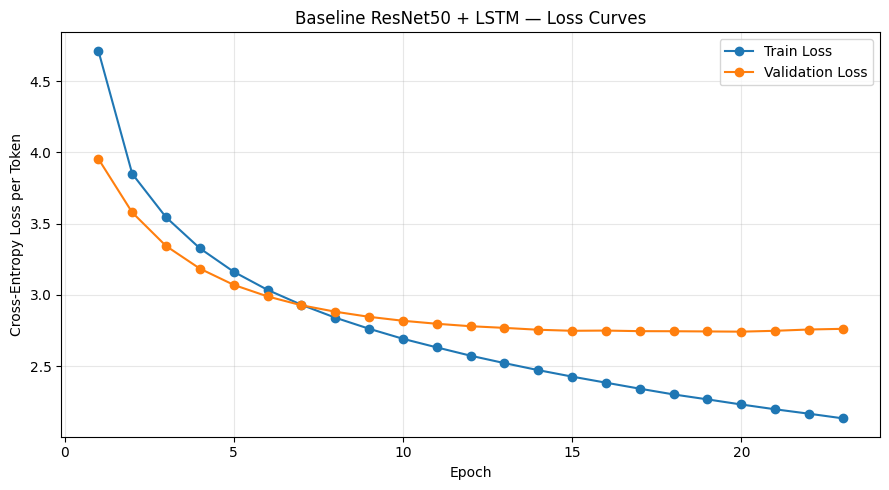

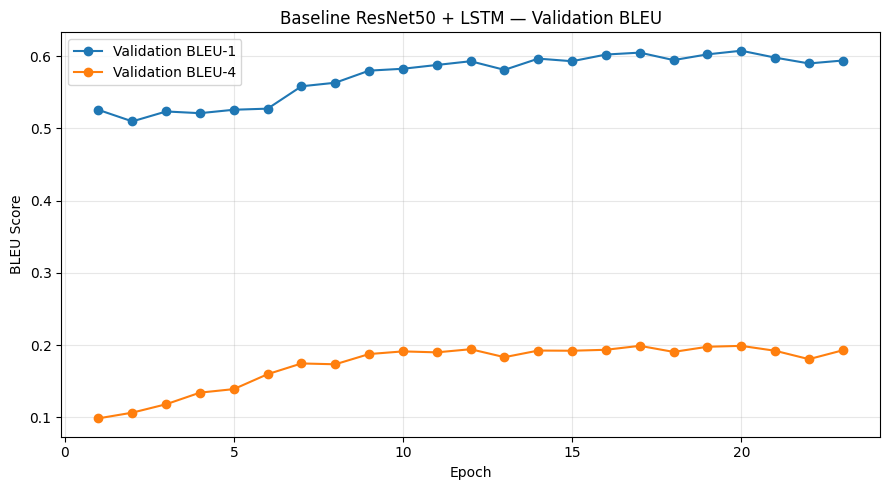

Saved: /kaggle/working/part1_baseline_v2/loss_curve.png
Saved: /kaggle/working/part1_baseline_v2/validation_bleu_curve.png
Saved: /kaggle/working/part1_baseline_v2/training_history.csv


In [11]:
history_df = pd.DataFrame(history)
display(history_df)

history_csv_path = os.path.join(CFG.OUTPUT_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

# Loss curve
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss per Token")
plt.title("Baseline ResNet50 + LSTM — Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(CFG.OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_curve_path, dpi=160, bbox_inches="tight")
plt.show()

# BLEU curve
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["val_bleu1"], marker="o", label="Validation BLEU-1")
plt.plot(history_df["epoch"], history_df["val_bleu4"], marker="o", label="Validation BLEU-4")
plt.xlabel("Epoch")
plt.ylabel("BLEU Score")
plt.title("Baseline ResNet50 + LSTM — Validation BLEU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

bleu_curve_path = os.path.join(CFG.OUTPUT_DIR, "validation_bleu_curve.png")
plt.savefig(bleu_curve_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", loss_curve_path)
print("Saved:", bleu_curve_path)
print("Saved:", history_csv_path)

## 12. Automatic Convergence / Overfitting Summary

In [12]:
if len(history_df) > 0:
    min_val_idx = history_df["val_loss"].idxmin()
    best_bleu_idx = history_df["val_bleu4"].idxmax()

    min_val_epoch = int(history_df.loc[min_val_idx, "epoch"])
    best_bleu_epoch = int(history_df.loc[best_bleu_idx, "epoch"])

    print(
        f"Minimum validation loss: "
        f"{history_df.loc[min_val_idx, 'val_loss']:.4f} "
        f"at epoch {min_val_epoch}"
    )

    print(
        f"Maximum validation BLEU-4: "
        f"{history_df.loc[best_bleu_idx, 'val_bleu4']:.4f} "
        f"at epoch {best_bleu_epoch}"
    )

    if min_val_epoch < int(history_df["epoch"].max()):
        later = history_df[history_df["epoch"] > min_val_epoch]

        if (
            len(later) > 0
            and later["train_loss"].iloc[-1]
            < history_df.loc[min_val_idx, "train_loss"]
            and later["val_loss"].iloc[-1]
            > history_df.loc[min_val_idx, "val_loss"]
        ):
            print(
                "\nInterpretation: training loss continued to decrease after "
                "the minimum validation loss while validation loss increased. "
                "This is evidence of overfitting in the later epochs."
            )

Minimum validation loss: 2.7414 at epoch 20
Maximum validation BLEU-4: 0.1989 at epoch 17

Interpretation: training loss continued to decrease after the minimum validation loss while validation loss increased. This is evidence of overfitting in the later epochs.


## 13. Final Test Evaluation

The **best validation BLEU-4 checkpoint** is loaded before touching the test metrics.

In [13]:
best_checkpoint = load_best_model(best_ckpt_path)

print(
    "Loaded best model from epoch:",
    int(best_checkpoint["epoch"]) + 1,
)
print(
    "Checkpoint validation BLEU-4:",
    f"{best_checkpoint['best_val_bleu4']:.4f}",
)

test_result = evaluate_bleu(
    references=test_references,
    batch_size=CFG.BATCH_SIZE,
)

test_bleu1 = test_result["bleu1"]
test_bleu4 = test_result["bleu4"]

end_rate = float(np.mean(test_result["finished"]))
no_end_rate = 1.0 - end_rate

print(f"\nTest BLEU-1: {test_bleu1:.4f}")
print(f"Test BLEU-4: {test_bleu4:.4f}")
print(f"Generated <end> successfully: {100 * end_rate:.2f}%")
print(f"Reached decoding limit without <end>: {100 * no_end_rate:.2f}%")

metrics = {
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "dataset": manifest["dataset"],
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "selection_metric": "validation_bleu4",
    "best_checkpoint_epoch": int(best_checkpoint["epoch"]) + 1,
    "best_validation_bleu4": float(best_checkpoint["best_val_bleu4"]),
    "test_bleu1": float(test_bleu1),
    "test_bleu4": float(test_bleu4),
    "test_end_token_rate": float(end_rate),
    "test_no_end_rate": float(no_end_rate),
    "num_test_images": len(test_result["image_names"]),
}

metrics_path = os.path.join(CFG.OUTPUT_DIR, "test_metrics.json")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", metrics_path)

Loaded best model from epoch: 17
Checkpoint validation BLEU-4: 0.1989


BLEU decoding:   0%|          | 0/7 [00:00<?, ?it/s]


Test BLEU-1: 0.5980
Test BLEU-4: 0.1969
Generated <end> successfully: 99.01%
Reached decoding limit without <end>: 0.99%
Saved: /kaggle/working/part1_baseline_v2/test_metrics.json


## 14. Locate the Original Flickr8k Images for Qualitative Test Examples

The locator scores directories by how many **actual test-image filenames** they contain.  
This prevents the old mistake of accidentally selecting the preprocessing output directory because it contains one PNG grid.

In [14]:

def directory_matches_raw_flickr8k(path, test_image_names):
    if path is None or not os.path.isdir(path):
        return False

    targets = set(
        test_image_names[
            : min(
                200,
                len(test_image_names),
            )
        ]
    )

    try:
        files = set(
            name
            for name in os.listdir(path)
            if name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        )
    except Exception:
        return False

    # Require a real Flickr8k-scale image directory and strong test-name matching.
    return (
        len(files) >= 7000
        and len(targets & files) >= min(150, len(targets))
    )


def locate_raw_images_dir(test_image_names):
    if CFG.RAW_IMAGES_DIR is not None:
        assert directory_matches_raw_flickr8k(
            CFG.RAW_IMAGES_DIR,
            test_image_names,
        ), (
            "CFG.RAW_IMAGES_DIR does not look like the raw Flickr8k Images directory."
        )

        return CFG.RAW_IMAGES_DIR

    # First try the exact source recorded by Notebook 01.
    manifest_source = manifest.get(
        "source_images_dir"
    )

    if directory_matches_raw_flickr8k(
        manifest_source,
        test_image_names,
    ):
        return manifest_source

    targets = set(
        test_image_names[
            : min(
                200,
                len(test_image_names),
            )
        ]
    )

    candidates = []

    # Raw datasets should be attached under /kaggle/input.
    for root in ["/kaggle/input"]:
        if not os.path.exists(root):
            continue

        for dirpath, _, filenames in os.walk(root):
            image_files = [
                f
                for f in filenames
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                )
            ]

            if len(image_files) < 7000:
                continue

            matches = len(
                targets
                & set(image_files)
            )

            candidates.append(
                (
                    matches,
                    len(image_files),
                    dirpath,
                )
            )

    if not candidates:
        return None

    candidates.sort(
        reverse=True
    )

    best_matches, _, best_dir = candidates[0]

    if best_matches < min(
        150,
        len(targets),
    ):
        return None

    return best_dir


RAW_IMAGES_DIR = locate_raw_images_dir(
    test_result["image_names"]
)

if RAW_IMAGES_DIR is None:
    print(
        "WARNING: raw Flickr8k images were not found. "
        "Attach adityajn105/flickr8k (or the same raw Flickr8k dataset used in Notebook 01)."
    )
else:
    print(
        "Raw Flickr8k images directory:",
        RAW_IMAGES_DIR,
    )


Raw Flickr8k images directory: /kaggle/input/datasets/adityajn105/flickr8k/Images


## 15. Qualitative Test Examples — Image + Ground Truth + Generated Caption

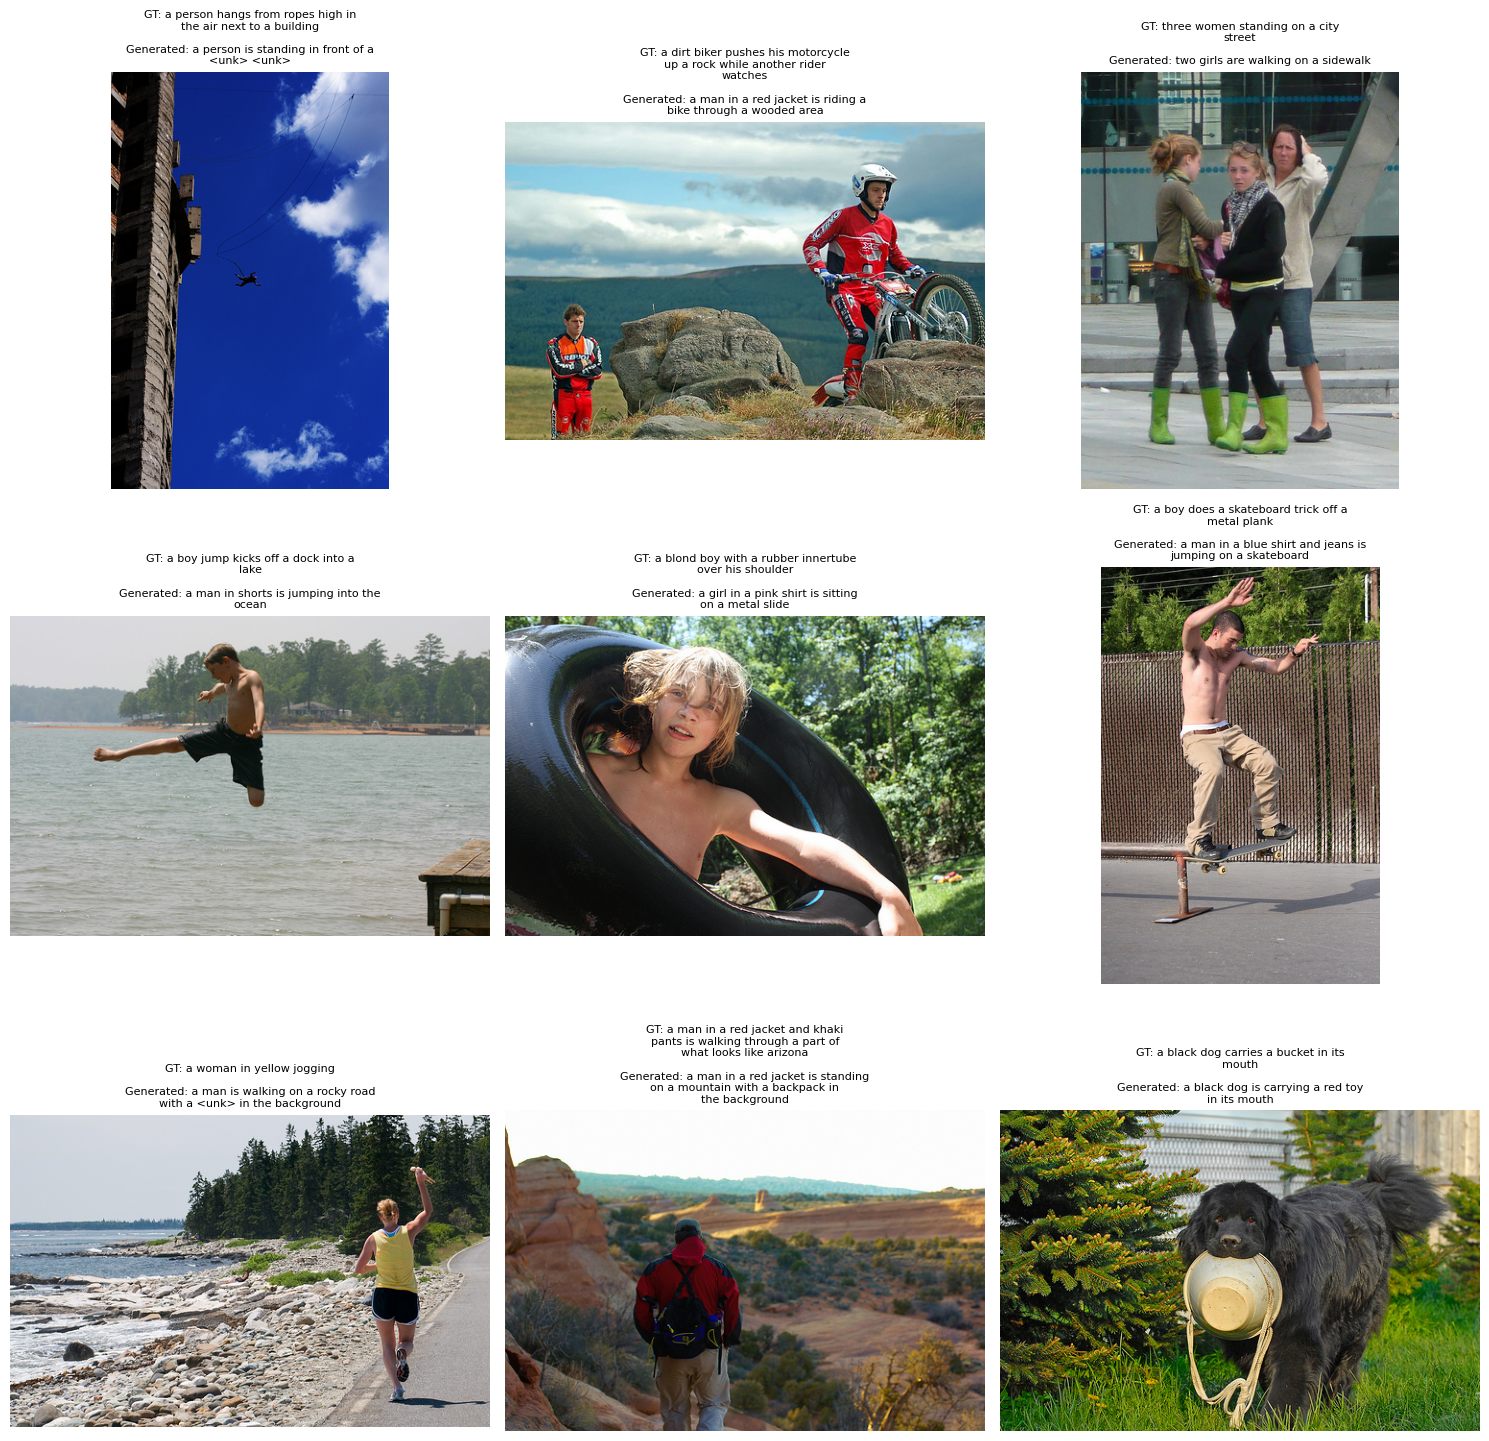

Saved: /kaggle/working/part1_baseline_v2/test_sample_generations.png


In [15]:
def find_image_path(image_name, root):
    direct = os.path.join(root, image_name)

    if os.path.exists(direct):
        return direct

    matches = list(Path(root).rglob(image_name))
    return str(matches[0]) if matches else None


sample_figure_path = os.path.join(
    CFG.OUTPUT_DIR,
    "test_sample_generations.png",
)

if RAW_IMAGES_DIR is not None:
    rng = random.Random(CFG.SEED)

    sample_indices = rng.sample(
        range(len(test_result["image_names"])),
        min(9, len(test_result["image_names"])),
    )

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for ax, result_idx in zip(axes.flat, sample_indices):
        image_name = test_result["image_names"][result_idx]

        ground_truth = " ".join(
            test_result["references"][result_idx][0]
        )

        generated = " ".join(
            test_result["hypotheses"][result_idx]
        )

        image_path = find_image_path(
            image_name,
            RAW_IMAGES_DIR,
        )

        if image_path is not None:
            with Image.open(image_path) as image:
                ax.imshow(image.convert("RGB"))

        ax.axis("off")

        title = (
            "GT: "
            + textwrap.fill(ground_truth, 35)
            + "\n\nGenerated: "
            + textwrap.fill(generated if generated else "(empty)", 35)
        )

        ax.set_title(title, fontsize=8)

    plt.tight_layout()
    plt.savefig(
        sample_figure_path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", sample_figure_path)
else:
    print("Skipped qualitative image figure because raw images are unavailable.")

## 16. Error Analysis

The project explicitly asks for discussion of:

- incomplete or unnatural captions,
- repeated words,
- incorrect objects or relationships,
- simple versus complex images.

Automatic metrics can reliably flag **repetition**, **failure to generate `<end>`**, and low-BLEU outputs.  
Incorrect objects/relationships are visual-semantic errors, so the notebook exports low-scoring examples for manual inspection rather than pretending that BLEU alone can diagnose the exact semantic mistake.

In [16]:
def repetition_ratio(words):
    if len(words) <= 1:
        return 0.0

    return 1.0 - len(set(words)) / len(words)


def sample_bleu1(hypothesis, references):
    smoothing = SmoothingFunction().method1

    return sentence_bleu(
        references,
        hypothesis,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoothing,
    )


analysis_rows = []

for image_name, hypothesis, references, finished in zip(
    test_result["image_names"],
    test_result["hypotheses"],
    test_result["references"],
    test_result["finished"],
):
    reference_lengths = [len(ref) for ref in references]

    analysis_rows.append(
        {
            "image": image_name,
            "generated": " ".join(hypothesis),
            "ground_truth_1": " ".join(references[0]),
            "generated_length": len(hypothesis),
            "mean_reference_length": float(np.mean(reference_lengths)),
            "repetition_ratio": repetition_ratio(hypothesis),
            "bleu1": float(sample_bleu1(hypothesis, references)),
            "generated_end_token": bool(finished),
        }
    )

analysis_df = pd.DataFrame(analysis_rows)

# Explicitly label this as a proxy; it is NOT a ground-truth image-complexity label.
median_ref_len = analysis_df["mean_reference_length"].median()

analysis_df["caption_length_complexity_proxy"] = np.where(
    analysis_df["mean_reference_length"] <= median_ref_len,
    "short-reference proxy",
    "long-reference proxy",
)

print(
    "Noticeable repetition (> 0.30):",
    f"{100 * (analysis_df['repetition_ratio'] > 0.30).mean():.2f}%"
)

print(
    "No <end> before decoding limit:",
    f"{100 * (~analysis_df['generated_end_token']).mean():.2f}%"
)

print("\nBLEU-1 by reference-length proxy:")
display(
    analysis_df.groupby(
        "caption_length_complexity_proxy"
    )["bleu1"].agg(["mean", "median", "count"])
)

worst_examples = analysis_df.nsmallest(8, "bleu1")
best_examples = analysis_df.nlargest(8, "bleu1")
repetition_examples = analysis_df.nlargest(8, "repetition_ratio")
incomplete_examples = analysis_df[
    ~analysis_df["generated_end_token"]
].nsmallest(8, "bleu1")

print("\nWorst examples:")
display(
    worst_examples[
        ["image", "ground_truth_1", "generated", "bleu1"]
    ]
)

print("\nHighest repetition examples:")
display(
    repetition_examples[
        ["image", "ground_truth_1", "generated", "repetition_ratio"]
    ]
)

print("\nNo-END examples:")
display(
    incomplete_examples[
        ["image", "ground_truth_1", "generated", "bleu1"]
    ]
)

analysis_path = os.path.join(
    CFG.OUTPUT_DIR,
    "error_analysis.csv",
)

analysis_df.to_csv(analysis_path, index=False)

# Export report-ready subsets.
worst_examples.to_csv(
    os.path.join(CFG.OUTPUT_DIR, "worst_examples.csv"),
    index=False,
)

best_examples.to_csv(
    os.path.join(CFG.OUTPUT_DIR, "best_examples.csv"),
    index=False,
)

repetition_examples.to_csv(
    os.path.join(CFG.OUTPUT_DIR, "repetition_examples.csv"),
    index=False,
)

incomplete_examples.to_csv(
    os.path.join(CFG.OUTPUT_DIR, "incomplete_examples.csv"),
    index=False,
)

print("\nSaved:", analysis_path)

Noticeable repetition (> 0.30): 11.48%
No <end> before decoding limit: 0.99%

BLEU-1 by reference-length proxy:


,mean,median,count
caption_length_complexity_proxy,,,
long-reference proxy,0.592591,0.600000,385
short-reference proxy,0.573756,0.571429,425



Worst examples:


,image,ground_truth_1,generated,bleu1
32,1417295167_5299df6db8.jpg,a man holds a drink in one hand and looks at h...,two people are standing outside,0.000000
443,3217909454_7baa0edbb2.jpg,an older dark skinned woman holding a lighter ...,two young girls are smiling,0.000000
191,2488795251_c108c77b13.jpg,the girls smile at the camera,a woman in a white dress and a woman in a blue...,0.052632
763,543102698_38e7e38bbc.jpg,a little boy in a red shirt plays with a park ...,two girls are playing on a playground,0.069935
673,3677927146_1696f0b075.jpg,several large dogs are running through a large...,a black and white dog is jumping over a white dog,0.090909
415,3143155555_32b6d24f34.jpg,a toddler girl plays with another younger todd...,a baby in a blue shirt is holding a baby,0.100000
132,2301867590_98c0ecb0cb.jpg,the children make snow angels next to each other,a boy in a red jacket is riding a red sled dow...,0.133333
391,3091594712_2166604334.jpg,a child ballerina puts on make up backstage in...,two women in a <unk> room,0.144866



Highest repetition examples:


,image,ground_truth_1,generated,repetition_ratio
362,3006095077_1992b677f8.jpg,a couple of men in hats posing for a picture b...,a man in a black hat and a man with a black ha...,0.631579
412,3134387513_ceb75bea0a.jpg,a couple enjoying a bit of nightlife smile for...,a woman in a black jacket and a woman in a bla...,0.631579
88,2090387793_274ab4cf7d.jpg,a boy wearing black walks down the street with...,a man in a black jacket and a black jacket and...,0.588235
191,2488795251_c108c77b13.jpg,the girls smile at the camera,a woman in a white dress and a woman in a blue...,0.578947
212,2601008162_f00eeb5c14.jpg,a child is holding up a camera in front of its...,a woman with a camera and a camera with a camera,0.545455
395,3098714492_19939e3b19.jpg,a bride and groom pose with their wedding party,a man and woman in a white dress and a woman i...,0.533333
537,3411393875_a9ff73c67a.jpg,a man in a red shirt standing next to a woman ...,a man with a black shirt and a woman in a blue...,0.526316
43,1515025681_999199cb79.jpg,a man in a white shirt and sunglasses gazes in...,a man in a white shirt is holding a man in a w...,0.500000



No-END examples:


,image,ground_truth_1,generated,bleu1
191,2488795251_c108c77b13.jpg,the girls smile at the camera,a woman in a white dress and a woman in a blue...,0.052632
362,3006095077_1992b677f8.jpg,a couple of men in hats posing for a picture b...,a man in a black hat and a man with a black ha...,0.263158
536,3405100926_e96308ce89.jpg,a group of men in green shirts and black pants...,a man in a red shirt and white pants is wearin...,0.263158
412,3134387513_ceb75bea0a.jpg,a couple enjoying a bit of nightlife smile for...,a woman in a black jacket and a woman in a bla...,0.298479
340,2934359101_cdf57442dc.jpg,a boxer is being examined in his corner by a m...,a woman in a white and black shirt is holding ...,0.315789
172,2423550887_ffc9bbcf71.jpg,a man in a red coat stands in front of a light...,a person is walking on a <unk> with a red and ...,0.421053
666,3655964639_21e76383d0.jpg,a man chains his bike to a rack while a woman ...,a woman in a black jacket is walking down a st...,0.631579
537,3411393875_a9ff73c67a.jpg,a man in a red shirt standing next to a woman ...,a man with a black shirt and a woman in a blue...,0.736842



Saved: /kaggle/working/part1_baseline_v2/error_analysis.csv


## 17. Save Failure-Case Figure for Manual Object / Relation Analysis

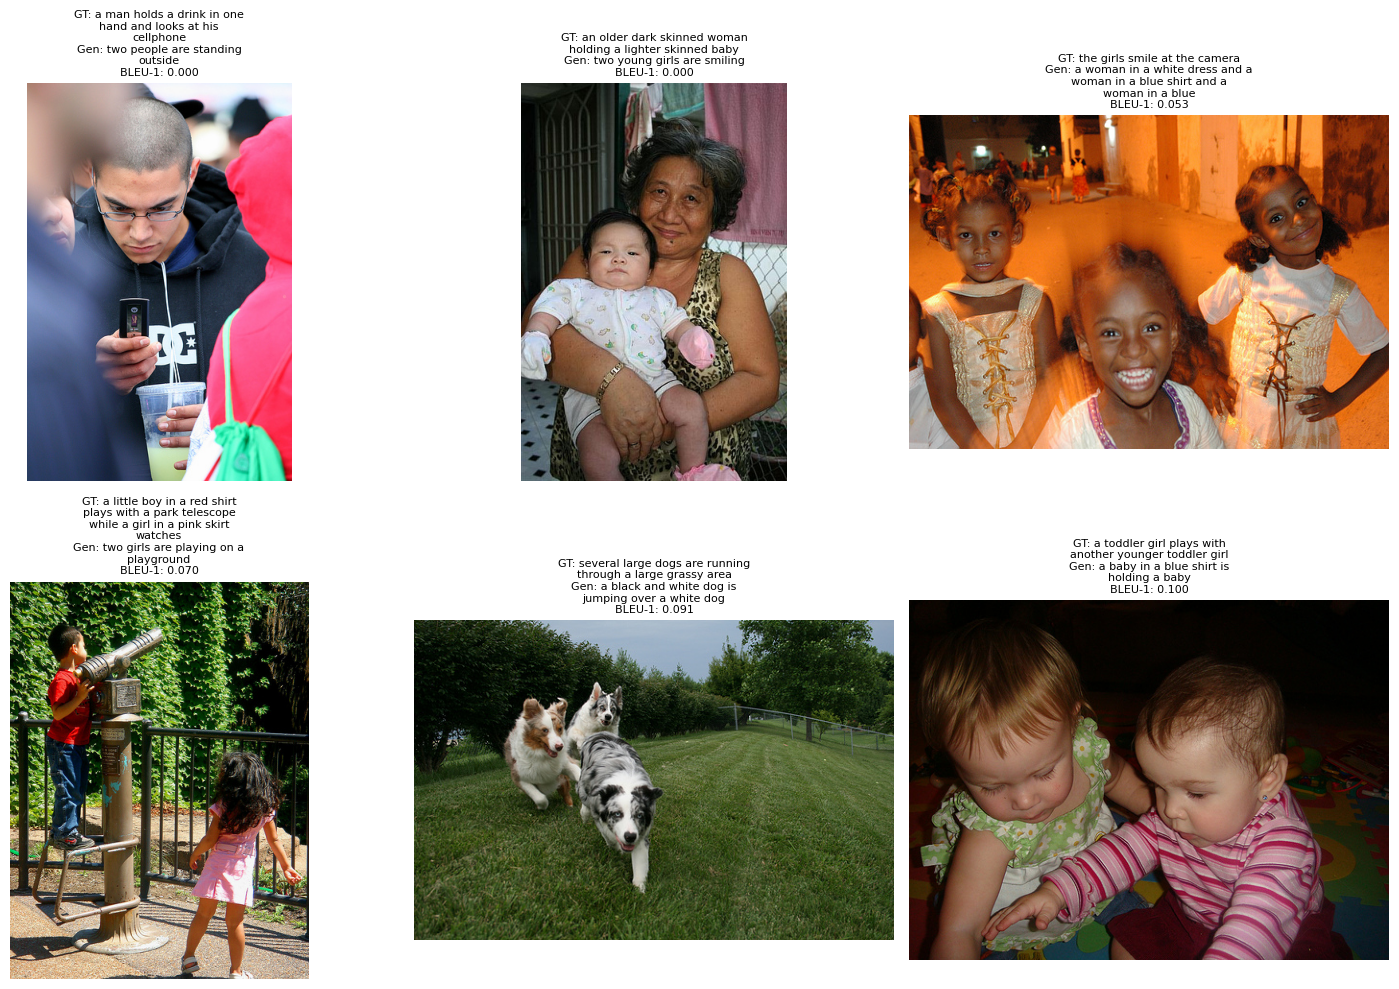

Saved: /kaggle/working/part1_baseline_v2/failure_cases_for_manual_analysis.png

Use these low-scoring cases in the written report to identify specific wrong-object or wrong-relation errors by visual inspection.


In [17]:
failure_figure_path = os.path.join(
    CFG.OUTPUT_DIR,
    "failure_cases_for_manual_analysis.png",
)

if RAW_IMAGES_DIR is not None and len(worst_examples) > 0:
    n_show = min(6, len(worst_examples))

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 10),
    )

    for ax, row in zip(
        axes.flat,
        worst_examples.head(n_show).itertuples(index=False),
    ):
        image_path = find_image_path(
            row.image,
            RAW_IMAGES_DIR,
        )

        if image_path is not None:
            with Image.open(image_path) as image:
                ax.imshow(image.convert("RGB"))

        ax.axis("off")
        ax.set_title(
            "GT: "
            + textwrap.fill(row.ground_truth_1, 30)
            + "\nGen: "
            + textwrap.fill(row.generated, 30)
            + f"\nBLEU-1: {row.bleu1:.3f}",
            fontsize=8,
        )

    # Hide any unused axes.
    for ax in axes.flat[n_show:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(
        failure_figure_path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", failure_figure_path)
    print(
        "\nUse these low-scoring cases in the written report to identify "
        "specific wrong-object or wrong-relation errors by visual inspection."
    )
else:
    print("Skipped failure-case image figure because raw images are unavailable.")

## 18. Hyperparameter Table

In [18]:
hyperparameters = {
    "Learning Rate": CFG.LR,
    "Batch Size": CFG.BATCH_SIZE,
    "Epochs Trained": len(history["epoch"]),
    "Maximum Epochs": CFG.MAX_EPOCHS,
    "Early-Stopping Patience": CFG.PATIENCE,
    "Optimizer": CFG.OPTIMIZER_NAME,
    "Weight Decay": CFG.WEIGHT_DECAY,
    "Gradient Clip Norm": CFG.GRAD_CLIP,
    "Encoder": CFG.ENCODER_NAME,
    "Cached Spatial Feature Shape": f"{NUM_TOKENS} × {FEAT_DIM}",
    "LSTM Input Image Feature": f"mean pooled → {FEAT_DIM}",
    "Decoder": CFG.DECODER_NAME,
    "Embedding Dimension": CFG.EMBED_DIM,
    "Hidden Dimension": CFG.HIDDEN_DIM,
    "Number of LSTM Layers": CFG.NUM_LAYERS,
    "Dropout": CFG.DROPOUT,
    "Vocabulary Size": VOCAB_SIZE,
    "Max Caption Length": MAX_LEN,
    "Generation Strategy": "Greedy decoding",
    "Best-Model Selection": "Full validation BLEU-4",
    "Test BLEU-1": round(test_bleu1, 4),
    "Test BLEU-4": round(test_bleu4, 4),
}

hyperparameters_df = pd.DataFrame(
    list(hyperparameters.items()),
    columns=["Hyperparameter", "Value"],
)

display(hyperparameters_df)

hyperparameters_path = os.path.join(
    CFG.OUTPUT_DIR,
    "hyperparameters_table.csv",
)

hyperparameters_df.to_csv(
    hyperparameters_path,
    index=False,
)

print("Saved:", hyperparameters_path)

,Hyperparameter,Value
0,Learning Rate,0.0003
1,Batch Size,128
2,Epochs Trained,23
3,Maximum Epochs,30
4,Early-Stopping Patience,6
5,Optimizer,Adam
6,Weight Decay,0.00001
7,Gradient Clip Norm,5.0
8,Encoder,ResNet50 ImageNet-V2 (frozen; precomputed spat...
9,Cached Spatial Feature Shape,49 × 2048


Saved: /kaggle/working/part1_baseline_v2/hyperparameters_table.csv


# 19. Save the Final Learned Model

This is the **guaranteed final model artifact** produced after training.

`baseline_lstm_final_model.pt` contains:

- the best learned LSTM decoder weights,
- architecture dimensions,
- vocabulary,
- special-token IDs,
- preprocessing metadata,
- test metrics,
- best validation BLEU-4.

It can be loaded later together with ResNet50 features or with the optional end-to-end presentation model created in the next section.

In [19]:
# Ensure the best learned weights are active.
best_checkpoint = load_best_model(best_ckpt_path)

final_model_path = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.FINAL_MODEL,
)

# Move state tensors to CPU for portable saving.
decoder_state_cpu = {
    key: value.detach().cpu()
    for key, value in model.state_dict().items()
}

final_model_bundle = {
    "format_version": 2,
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "model_name": "Baseline ResNet50 + LSTM Image Captioner",
    "selection_metric": "validation_bleu4",
    "best_epoch": int(best_checkpoint["epoch"]) + 1,
    "best_validation_bleu4": float(
        best_checkpoint["best_val_bleu4"]
    ),
    "test_metrics": metrics,

    "decoder_state_dict": decoder_state_cpu,

    "model_config": {
        "vocab_size": VOCAB_SIZE,
        "feat_dim": FEAT_DIM,
        "embed_dim": CFG.EMBED_DIM,
        "hidden_dim": CFG.HIDDEN_DIM,
        "num_layers": CFG.NUM_LAYERS,
        "dropout": CFG.DROPOUT,
        "pad_id": PAD_ID,
    },

    "generation_config": {
        "start_id": START_ID,
        "end_id": END_ID,
        "pad_id": PAD_ID,
        "unk_id": UNK_ID,
        "max_new_tokens": GEN_MAX_NEW_TOKENS,
        "strategy": "greedy",
    },

    "encoder_config": {
        "name": "resnet50",
        "weights": "IMAGENET1K_V2",
        "feature_mode": "spatial_then_mean_pool",
        "num_spatial_tokens": NUM_TOKENS,
        "feature_dim": FEAT_DIM,
    },

    "image_transform": manifest["image_transform"],

    "vocabulary": {
        "word2idx": word2idx,
        "idx2word": idx2word,
    },
}

torch.save(
    final_model_bundle,
    final_model_path,
)

print("Final learned model saved:")
print(final_model_path)
print(
    "Size:",
    f"{os.path.getsize(final_model_path) / 1e6:.2f} MB",
)

Final learned model saved:
/kaggle/working/part1_baseline_v2/baseline_lstm_final_model.pt
Size: 18.78 MB


# 20. Build a Self-Contained End-to-End Presentation Model

For a presentation, it is convenient to provide a raw image directly rather than preparing an HDF5 feature file.

This section attempts to package:

**raw image → ResNet50 → mean pooling → LSTM → caption**

into one saved bundle.

The ResNet50 weights must be available to torchvision once while this cell runs.  
After the bundle is created, those encoder weights are stored inside the `.pt` file.

In [20]:
class EndToEndCaptionModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_id,
    ):
        super().__init__()

        base_resnet = tvm.resnet50(weights=None)

        # Keep convolutional encoder only.
        self.encoder = nn.Sequential(
            *list(base_resnet.children())[:-2]
        )

        self.decoder = CaptionLSTM(
            vocab_size=vocab_size,
            feat_dim=2048,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            pad_id=pad_id,
        )

    def encode(self, images):
        features = self.encoder(images)             # (B, 2048, 7, 7)
        features = features.flatten(2).transpose(1, 2)  # (B, 49, 2048)
        global_features = features.mean(dim=1)      # (B, 2048)
        return global_features

    def forward(self, images, input_tokens):
        global_features = self.encode(images)
        return self.decoder(global_features, input_tokens)

    @torch.no_grad()
    def generate(
        self,
        images,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
    ):
        global_features = self.encode(images)

        return self.decoder.generate(
            global_features,
            start_id=start_id,
            end_id=end_id,
            pad_id=pad_id,
            max_new_tokens=max_new_tokens,
        )


full_presentation_model_path = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.FULL_PRESENTATION_MODEL,
)

full_bundle_created = False

try:
    print("Loading exact pretrained ResNet50 ImageNet-V2 encoder weights...")

    pretrained_resnet = tvm.resnet50(
        weights=tvm.ResNet50_Weights.IMAGENET1K_V2
    )

    pretrained_encoder = nn.Sequential(
        *list(pretrained_resnet.children())[:-2]
    )

    full_model = EndToEndCaptionModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=CFG.EMBED_DIM,
        hidden_dim=CFG.HIDDEN_DIM,
        num_layers=CFG.NUM_LAYERS,
        dropout=CFG.DROPOUT,
        pad_id=PAD_ID,
    )

    full_model.encoder.load_state_dict(
        pretrained_encoder.state_dict()
    )

    full_model.decoder.load_state_dict(
        model.state_dict()
    )

    full_model.eval()

    full_state_cpu = {
        key: value.detach().cpu()
        for key, value in full_model.state_dict().items()
    }

    full_presentation_bundle = {
        "format_version": 1,
        "model_name": "End-to-End ResNet50 + LSTM Image Captioner",
        "state_dict": full_state_cpu,

        "model_config": {
            "vocab_size": VOCAB_SIZE,
            "embed_dim": CFG.EMBED_DIM,
            "hidden_dim": CFG.HIDDEN_DIM,
            "num_layers": CFG.NUM_LAYERS,
            "dropout": CFG.DROPOUT,
            "pad_id": PAD_ID,
        },

        "generation_config": {
            "start_id": START_ID,
            "end_id": END_ID,
            "pad_id": PAD_ID,
            "unk_id": UNK_ID,
            "max_new_tokens": GEN_MAX_NEW_TOKENS,
            "strategy": "greedy",
        },

        "image_transform": {
            "resize_size": 232,
            "crop_size": 224,
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
        },

        "vocabulary": {
            "word2idx": word2idx,
            "idx2word": idx2word,
        },

        "metrics": metrics,
    }

    torch.save(
        full_presentation_bundle,
        full_presentation_model_path,
    )

    full_bundle_created = True

    print("\nSelf-contained presentation model saved:")
    print(full_presentation_model_path)
    print(
        "Size:",
        f"{os.path.getsize(full_presentation_model_path) / 1e6:.2f} MB",
    )

    del pretrained_resnet, pretrained_encoder, full_model
    gc.collect()

except Exception as exc:
    print("\nCould not build the full end-to-end bundle.")
    print("Reason:", repr(exc))
    print(
        "\nThe compact learned model was still saved successfully as:\n",
        final_model_path,
    )
    print(
        "\nIf this failed because torchvision could not obtain the pretrained "
        "ResNet50 weights, enable Kaggle Internet once or make the weights "
        "available in the PyTorch cache, then rerun only this cell."
    )

Loading exact pretrained ResNet50 ImageNet-V2 encoder weights...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]



Self-contained presentation model saved:
/kaggle/working/part1_baseline_v2/baseline_lstm_full_presentation_bundle.pt
Size: 113.13 MB


## 21. Create a Standalone Presentation Inference Script

The generated script accepts a raw image and the full presentation bundle:

```bash
python presentation_inference.py \
  --model baseline_lstm_full_presentation_bundle.pt \
  --image sample.jpg
```

In [21]:
inference_script = r"""
import argparse
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as tvm
import torchvision.transforms as T


class CaptionLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        feat_dim,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_id,
    ):
        super().__init__()

        self.image_proj = nn.Linear(feat_dim, embed_dim)
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_id,
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_feat, input_tokens):
        img_embed = torch.tanh(self.image_proj(img_feat))
        word_embed = self.embedding(input_tokens)
        img_rep = img_embed.unsqueeze(1).expand(
            -1, word_embed.size(1), -1
        )
        x = torch.cat([word_embed, img_rep], dim=-1)
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out))

    @torch.no_grad()
    def generate(
        self,
        img_feat,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
    ):
        batch_size = img_feat.size(0)
        img_embed = torch.tanh(
            self.image_proj(img_feat)
        ).unsqueeze(1)

        input_token = torch.full(
            (batch_size, 1),
            start_id,
            dtype=torch.long,
            device=img_feat.device,
        )

        hidden = None

        generated = torch.full(
            (batch_size, max_new_tokens),
            pad_id,
            dtype=torch.long,
            device=img_feat.device,
        )

        finished = torch.zeros(
            batch_size,
            dtype=torch.bool,
            device=img_feat.device,
        )

        for t in range(max_new_tokens):
            word_embed = self.embedding(input_token)
            x = torch.cat([word_embed, img_embed], dim=-1)
            out, hidden = self.lstm(x, hidden)
            logits = self.fc(out.squeeze(1))

            logits[:, pad_id] = -torch.inf
            logits[:, start_id] = -torch.inf

            next_token = logits.argmax(dim=-1)

            next_token = torch.where(
                finished,
                torch.full_like(next_token, pad_id),
                next_token,
            )

            generated[:, t] = next_token

            just_finished = (~finished) & (
                next_token == end_id
            )
            finished = finished | just_finished

            next_input = torch.where(
                finished,
                torch.full_like(next_token, end_id),
                next_token,
            )

            input_token = next_input.unsqueeze(1)

            if finished.all():
                break

        return generated


class EndToEndCaptionModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_id,
    ):
        super().__init__()

        base_resnet = tvm.resnet50(weights=None)

        self.encoder = nn.Sequential(
            *list(base_resnet.children())[:-2]
        )

        self.decoder = CaptionLSTM(
            vocab_size=vocab_size,
            feat_dim=2048,
            embed_dim=embed_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            pad_id=pad_id,
        )

    def encode(self, images):
        x = self.encoder(images)
        x = x.flatten(2).transpose(1, 2)
        return x.mean(dim=1)

    @torch.no_grad()
    def generate(
        self,
        images,
        start_id,
        end_id,
        pad_id,
        max_new_tokens,
    ):
        feat = self.encode(images)

        return self.decoder.generate(
            feat,
            start_id,
            end_id,
            pad_id,
            max_new_tokens,
        )


def load_captioner(model_path, device):
    bundle = torch.load(
        model_path,
        map_location=device,
    )

    cfg = bundle["model_config"]
    gen_cfg = bundle["generation_config"]

    model = EndToEndCaptionModel(
        vocab_size=cfg["vocab_size"],
        embed_dim=cfg["embed_dim"],
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        pad_id=cfg["pad_id"],
    )

    model.load_state_dict(bundle["state_dict"])
    model.to(device)
    model.eval()

    return model, bundle, gen_cfg


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--model",
        required=True,
        help="Path to baseline_lstm_full_presentation_bundle.pt",
    )

    parser.add_argument(
        "--image",
        required=True,
        help="Path to an input image",
    )

    args = parser.parse_args()

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model, bundle, gen_cfg = load_captioner(
        args.model,
        device,
    )

    tf_cfg = bundle["image_transform"]

    transform = T.Compose(
        [
            T.Resize(tf_cfg["resize_size"]),
            T.CenterCrop(tf_cfg["crop_size"]),
            T.ToTensor(),
            T.Normalize(
                mean=tf_cfg["mean"],
                std=tf_cfg["std"],
            ),
        ]
    )

    with Image.open(args.image) as image:
        image = image.convert("RGB")
        x = transform(image).unsqueeze(0).to(device)

    generated = model.generate(
        x,
        start_id=gen_cfg["start_id"],
        end_id=gen_cfg["end_id"],
        pad_id=gen_cfg["pad_id"],
        max_new_tokens=gen_cfg["max_new_tokens"],
    )[0].tolist()

    idx2word = bundle["vocabulary"]["idx2word"]

    words = []

    for token_id in generated:
        if token_id == gen_cfg["end_id"]:
            break

        if token_id in (
            gen_cfg["pad_id"],
            gen_cfg["start_id"],
        ):
            continue

        words.append(idx2word[token_id])

    print("Generated caption:")
    print(" ".join(words))


if __name__ == "__main__":
    main()
""".strip()

presentation_script_path = os.path.join(
    CFG.OUTPUT_DIR,
    CFG.PRESENTATION_SCRIPT,
)

with open(
    presentation_script_path,
    "w",
    encoding="utf-8",
) as f:
    f.write(inference_script)

print("Saved:", presentation_script_path)

Saved: /kaggle/working/part1_baseline_v2/presentation_inference.py


## 22. Optional End-to-End Demo Verification

Demo image: 1007129816_e794419615.jpg
Generated caption: a man wearing a hat and sunglasses is wearing a hat


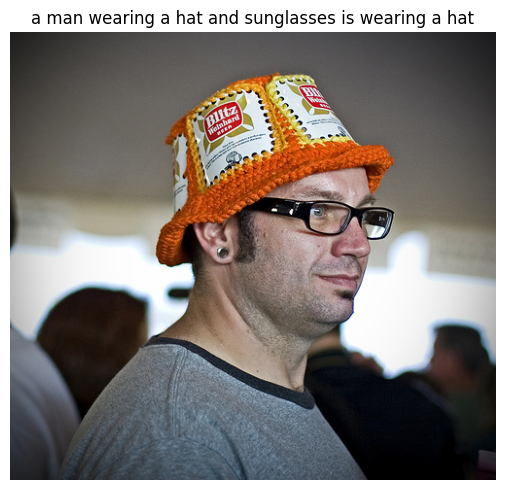

In [22]:
if full_bundle_created and RAW_IMAGES_DIR is not None:
    demo_image_name = test_result["image_names"][0]
    demo_image_path = find_image_path(
        demo_image_name,
        RAW_IMAGES_DIR,
    )

    if demo_image_path is not None:
        bundle = torch.load(
            full_presentation_model_path,
            map_location=DEVICE,
        )

        cfg = bundle["model_config"]

        demo_model = EndToEndCaptionModel(
            vocab_size=cfg["vocab_size"],
            embed_dim=cfg["embed_dim"],
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            pad_id=cfg["pad_id"],
        ).to(DEVICE)

        demo_model.load_state_dict(
            bundle["state_dict"]
        )
        demo_model.eval()

        tf_cfg = bundle["image_transform"]

        demo_transform = T.Compose(
            [
                T.Resize(tf_cfg["resize_size"]),
                T.CenterCrop(tf_cfg["crop_size"]),
                T.ToTensor(),
                T.Normalize(
                    mean=tf_cfg["mean"],
                    std=tf_cfg["std"],
                ),
            ]
        )

        with Image.open(demo_image_path) as image:
            rgb = image.convert("RGB")
            tensor = demo_transform(rgb).unsqueeze(0).to(DEVICE)

        generated_ids, _ = demo_model.generate(
            tensor,
            start_id=START_ID,
            end_id=END_ID,
            pad_id=PAD_ID,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
        )

        demo_caption = " ".join(
            ids_to_words(
                generated_ids[0].cpu().tolist()
            )
        )

        print("Demo image:", demo_image_name)
        print("Generated caption:", demo_caption)

        plt.figure(figsize=(7, 5))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title(demo_caption)
        plt.tight_layout()
        plt.show()

        del demo_model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
else:
    print(
        "End-to-end verification skipped because either the full bundle "
        "or the raw Flickr8k images are unavailable."
    )

## 23. Final Manifest and Presentation Package

In [23]:
# Refresh file listing before writing final manifest.
existing_files = [
    p for p in Path(CFG.OUTPUT_DIR).iterdir()
    if p.is_file()
]

part1_manifest = {
    "artifact_version": 2,
    "preprocessing_fingerprint": PREPROCESSING_FINGERPRINT,
    "preprocessing_directory_used": PREP_DIR,
    "project_section": "Part 1 - Baseline Image Captioning",
    "architecture": "Frozen ResNet50 + LSTM",
    "best_model_selection": "Full validation BLEU-4",
    "hyperparameters": hyperparameters,
    "test_metrics": metrics,
    "preprocessing_manifest": manifest,
    "final_model": CFG.FINAL_MODEL,
    "full_presentation_model": (
        CFG.FULL_PRESENTATION_MODEL
        if full_bundle_created
        else None
    ),
    "presentation_inference_script": CFG.PRESENTATION_SCRIPT,
}

manifest_path = os.path.join(
    CFG.OUTPUT_DIR,
    "part1_manifest.json",
)

with open(
    manifest_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        part1_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )

# Create a compact presentation package.
package_dir = os.path.join(
    CFG.OUTPUT_DIR,
    "presentation_package",
)

os.makedirs(package_dir, exist_ok=True)

files_to_package = [
    final_model_path,
    presentation_script_path,
    metrics_path,
    hyperparameters_path,
    loss_curve_path,
    bleu_curve_path,
    history_csv_path,
    analysis_path,
    manifest_path,
]

if full_bundle_created:
    files_to_package.append(
        full_presentation_model_path
    )

for optional_path in [
    sample_figure_path,
    failure_figure_path,
]:
    if os.path.exists(optional_path):
        files_to_package.append(optional_path)

for source in files_to_package:
    if os.path.exists(source):
        shutil.copy2(
            source,
            os.path.join(
                package_dir,
                os.path.basename(source),
            ),
        )

zip_base = os.path.join(
    CFG.OUTPUT_DIR,
    "part1_presentation_package",
)

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    package_dir,
)

print("Final manifest:", manifest_path)
print("Presentation package:", zip_path)

Final manifest: /kaggle/working/part1_baseline_v2/part1_manifest.json
Presentation package: /kaggle/working/part1_baseline_v2/part1_presentation_package.zip


## 24. Final Output Summary

In [24]:
output_files = sorted(
    p for p in Path(CFG.OUTPUT_DIR).rglob("*")
    if p.is_file()
)

print("Part 1 completed.\n")

for path in output_files:
    relative = path.relative_to(CFG.OUTPUT_DIR)
    size_mb = path.stat().st_size / 1e6
    print(f"{str(relative):55s} {size_mb:9.2f} MB")

total_size_gb = sum(
    p.stat().st_size for p in output_files
) / 1e9

print(f"\nTotal output size: {total_size_gb:.3f} GB")

print("\nMost important files for the presentation:")
print("1.", os.path.join(CFG.OUTPUT_DIR, CFG.FINAL_MODEL))

if full_bundle_created:
    print("2.", full_presentation_model_path)
    print("3.", presentation_script_path)
    print("4.", zip_path)
else:
    print(
        "2. Full end-to-end bundle was not created. "
        "See the warning in Section 20."
    )

print("\nBest checkpoint retained for reproducibility:")
print(best_ckpt_path)

Part 1 completed.

baseline_lstm_final_model.pt                                18.78 MB
baseline_lstm_full_presentation_bundle.pt                  113.13 MB
best_checkpoint.pt                                          56.06 MB
best_examples.csv                                            0.00 MB
error_analysis.csv                                           0.16 MB
failure_cases_for_manual_analysis.png                        4.17 MB
hyperparameters_table.csv                                    0.00 MB
incomplete_examples.csv                                      0.00 MB
last_checkpoint.pt                                          56.06 MB
loss_curve.png                                               0.07 MB
part1_manifest.json                                          0.00 MB
part1_presentation_package.zip                             132.74 MB
presentation_inference.py                                    0.01 MB
presentation_package/baseline_lstm_final_model.pt           18.78 MB
presentation_pa